# Prediksi Loan Status — LightGBM (Without XAI)
Notebook ini melakukan:
1. **Prediksi** Loan_Status menggunakan LightGBM (threshold 0.5) pada 12 dataset transformasi
2. **Evaluasi** model: Accuracy, Precision, Recall, F1 Score
   - Summary Plot (Bar + Beeswarm)
   - Waterfall Plot (per prediksi)
   - Force Plot (per prediksi)
### Dataset yang digunakan:
| Transformasi | Original | Drop Outliers | Replace Outliers |
|---|---|---|---|
| Z-Score | df_zscore | df_zscore_drop | df_zscore_replace |
| Log | df_log | df_log_drop | df_log_replace |
| MinMax | df_minmax | df_minmax_drop | df_minmax_replace |
| Decimal | df_decimal | df_decimal_drop | df_decimal_replace |


## 1. Install & Import Library


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)
print('Semua library berhasil diimport!')


Semua library berhasil diimport!


## 2. Import Dataset dari preprocessing2


In [22]:
from preprocessing2 import (
    df_ti_zscore, df_ti_log, df_ti_minmax, df_ti_decimal,
    df_lair_zscore, df_lair_log, df_lair_minmax, df_lair_decimal,
    df_both_zscore, df_both_log, df_both_minmax, df_both_decimal,
    df_ti_zscore_drop, df_ti_log_drop, df_ti_minmax_drop, df_ti_decimal_drop,
    df_lair_zscore_drop, df_lair_log_drop, df_lair_minmax_drop, df_lair_decimal_drop,
    df_both_zscore_drop, df_both_log_drop, df_both_minmax_drop, df_both_decimal_drop,
    df_ti_zscore_replace, df_ti_log_replace, df_ti_minmax_replace, df_ti_decimal_replace,
    df_lair_zscore_replace, df_lair_log_replace, df_lair_minmax_replace, df_lair_decimal_replace,
    df_both_zscore_replace, df_both_log_replace, df_both_minmax_replace, df_both_decimal_replace
)
print('Semua 36 dataset berhasil diimport!')


Semua dataset berhasil diimport!


## 3. Definisi Fungsi LightGBM + Evaluasi
- Fitur (X) = semua kolom kecuali `Loan_ID` dan `Loan_Status`
- Target (y) = `Loan_Status`
- Split: **80% train / 20% test**
- LightGBM kernel RBF, prediksi dikonversi ke 0/1 dengan threshold **0.5**


In [23]:
def run_lgbm(df, dataset_name, test_size=0.2, random_state=42):
    df_clean = df.copy()
    if 'Loan_ID' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Loan_ID'])
    X = df_clean.drop(columns=['Loan_Status'])
    y = df_clean['Loan_Status']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    lgbm = LGBMClassifier(random_state=42)
    lgbm.fit(X_train, y_train)
    y_pred_raw = lgbm.predict(X_test)
    y_pred     = (y_pred_raw >= 0.5).astype(int)
    return {
        'Dataset'   : dataset_name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'y_pred_raw': y_pred_raw,
        'cm'        : confusion_matrix(y_test, y_pred),
        'model'     : lgbm,
        'X_train'   : X_train,
        'X_test'    : X_test,
        'feature_names': X.columns.tolist(),
    }
print('Fungsi SVR siap!')


Fungsi SVR siap!


## 4. Training Semua 12 Model


In [24]:
datasets = {
    'TI ZScore (Original)': df_ti_zscore,
    'TI Log (Original)': df_ti_log,
    'TI MinMax (Original)': df_ti_minmax,
    'TI Decimal (Original)': df_ti_decimal,
    'LAIR ZScore (Original)': df_lair_zscore,
    'LAIR Log (Original)': df_lair_log,
    'LAIR MinMax (Original)': df_lair_minmax,
    'LAIR Decimal (Original)': df_lair_decimal,
    'BOTH ZScore (Original)': df_both_zscore,
    'BOTH Log (Original)': df_both_log,
    'BOTH MinMax (Original)': df_both_minmax,
    'BOTH Decimal (Original)': df_both_decimal,
    'TI ZScore (Drop)': df_ti_zscore_drop,
    'TI Log (Drop)': df_ti_log_drop,
    'TI MinMax (Drop)': df_ti_minmax_drop,
    'TI Decimal (Drop)': df_ti_decimal_drop,
    'LAIR ZScore (Drop)': df_lair_zscore_drop,
    'LAIR Log (Drop)': df_lair_log_drop,
    'LAIR MinMax (Drop)': df_lair_minmax_drop,
    'LAIR Decimal (Drop)': df_lair_decimal_drop,
    'BOTH ZScore (Drop)': df_both_zscore_drop,
    'BOTH Log (Drop)': df_both_log_drop,
    'BOTH MinMax (Drop)': df_both_minmax_drop,
    'BOTH Decimal (Drop)': df_both_decimal_drop,
    'TI ZScore (Replace)': df_ti_zscore_replace,
    'TI Log (Replace)': df_ti_log_replace,
    'TI MinMax (Replace)': df_ti_minmax_replace,
    'TI Decimal (Replace)': df_ti_decimal_replace,
    'LAIR ZScore (Replace)': df_lair_zscore_replace,
    'LAIR Log (Replace)': df_lair_log_replace,
    'LAIR MinMax (Replace)': df_lair_minmax_replace,
    'LAIR Decimal (Replace)': df_lair_decimal_replace,
    'BOTH ZScore (Replace)': df_both_zscore_replace,
    'BOTH Log (Replace)': df_both_log_replace,
    'BOTH MinMax (Replace)': df_both_minmax_replace,
    'BOTH Decimal (Replace)': df_both_decimal_replace,
}

results = {}
for name, data in datasets.items():
    print(f'Training: {name} ...')
    results[name] = run_lgbm(data, name)

print('\nSemua model selesai ditraining!')


Training: ZScore (Original) ...
Training: ZScore (Drop) ...
Training: ZScore (Replace) ...
Training: Log (Original) ...
Training: Log (Drop) ...
Training: Log (Replace) ...
Training: MinMax (Original) ...
Training: MinMax (Drop) ...
Training: MinMax (Replace) ...
Training: Decimal (Original) ...
Training: Decimal (Drop) ...
Training: Decimal (Replace) ...

Semua model selesai ditraining!


## 5. Tabel Perbandingan Evaluasi
Hijau = nilai terbaik | Merah = nilai terendah


In [25]:
summary = pd.DataFrame([
    {
        'Dataset'   : r['Dataset'],
        'Accuracy'  : r['Accuracy'],
        'Precision' : r['Precision'],
        'Recall'    : r['Recall'],
        'F1 Score'  : r['F1 Score'],
    }
    for r in results.values()
]).sort_values('F1 Score', ascending=False).reset_index(drop=True)

summary.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1 Score'], color='lightgreen'
).highlight_min(
    subset=['Accuracy','Precision','Recall','F1 Score'], color='#ffcccc'
)

,Dataset,Accuracy,Precision,Recall,F1 Score
0,ZScore (Drop),0.862700,0.841500,0.985700,0.907900
1,MinMax (Drop),0.862700,0.841500,0.985700,0.907900
2,Decimal (Drop),0.862700,0.841500,0.985700,0.907900
3,ZScore (Replace),0.853700,0.831700,0.988200,0.903200
4,Decimal (Replace),0.853700,0.831700,0.988200,0.903200
5,MinMax (Original),0.853700,0.831700,0.988200,0.903200
6,MinMax (Replace),0.853700,0.831700,0.988200,0.903200
7,ZScore (Original),0.845500,0.823500,0.988200,0.898400
8,Decimal (Original),0.845500,0.823500,0.988200,0.898400
9,Log (Original),0.691100,0.691100,1.000000,0.817300


## 6. Visualisasi Perbandingan Metrik


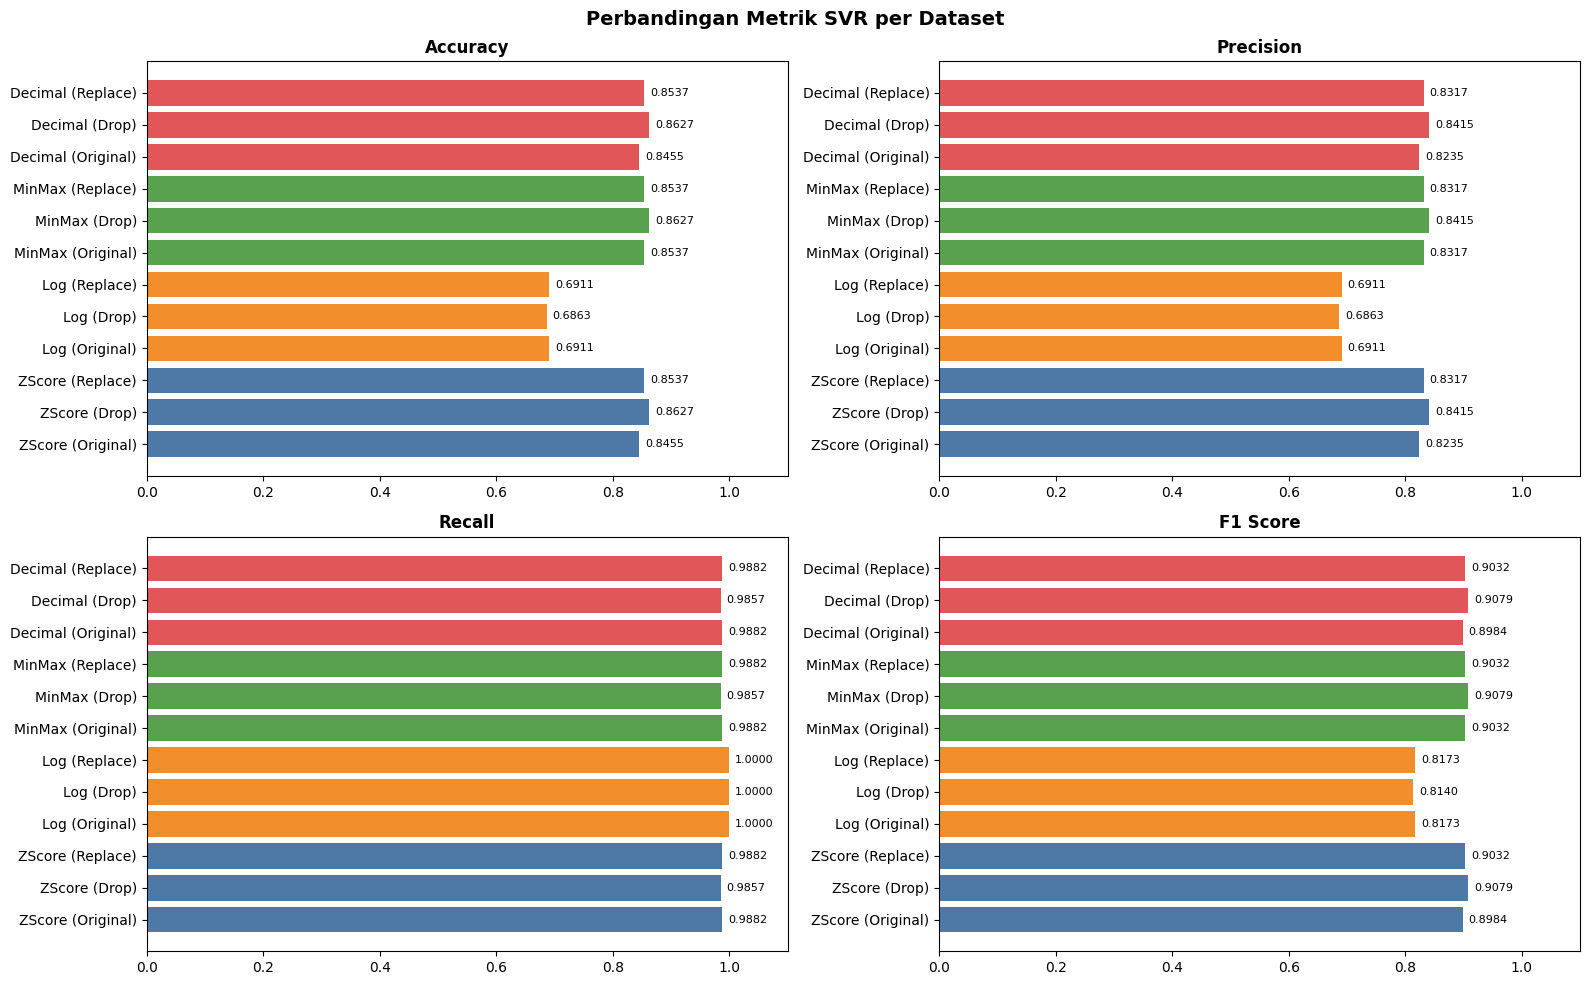

In [26]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#4e79a7']*3 + ['#f28e2b']*3 + ['#59a14f']*3 + ['#e15759']*3
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Perbandingan Metrik LightGBM per Dataset', fontsize=14, fontweight='bold')
for ax, metric in zip(axes.flatten(), metrics):
    vals = [results[n][metric] for n in datasets]
    bars = ax.barh(list(datasets.keys()), vals, color=colors)
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 7. Confusion Matrix Semua Dataset


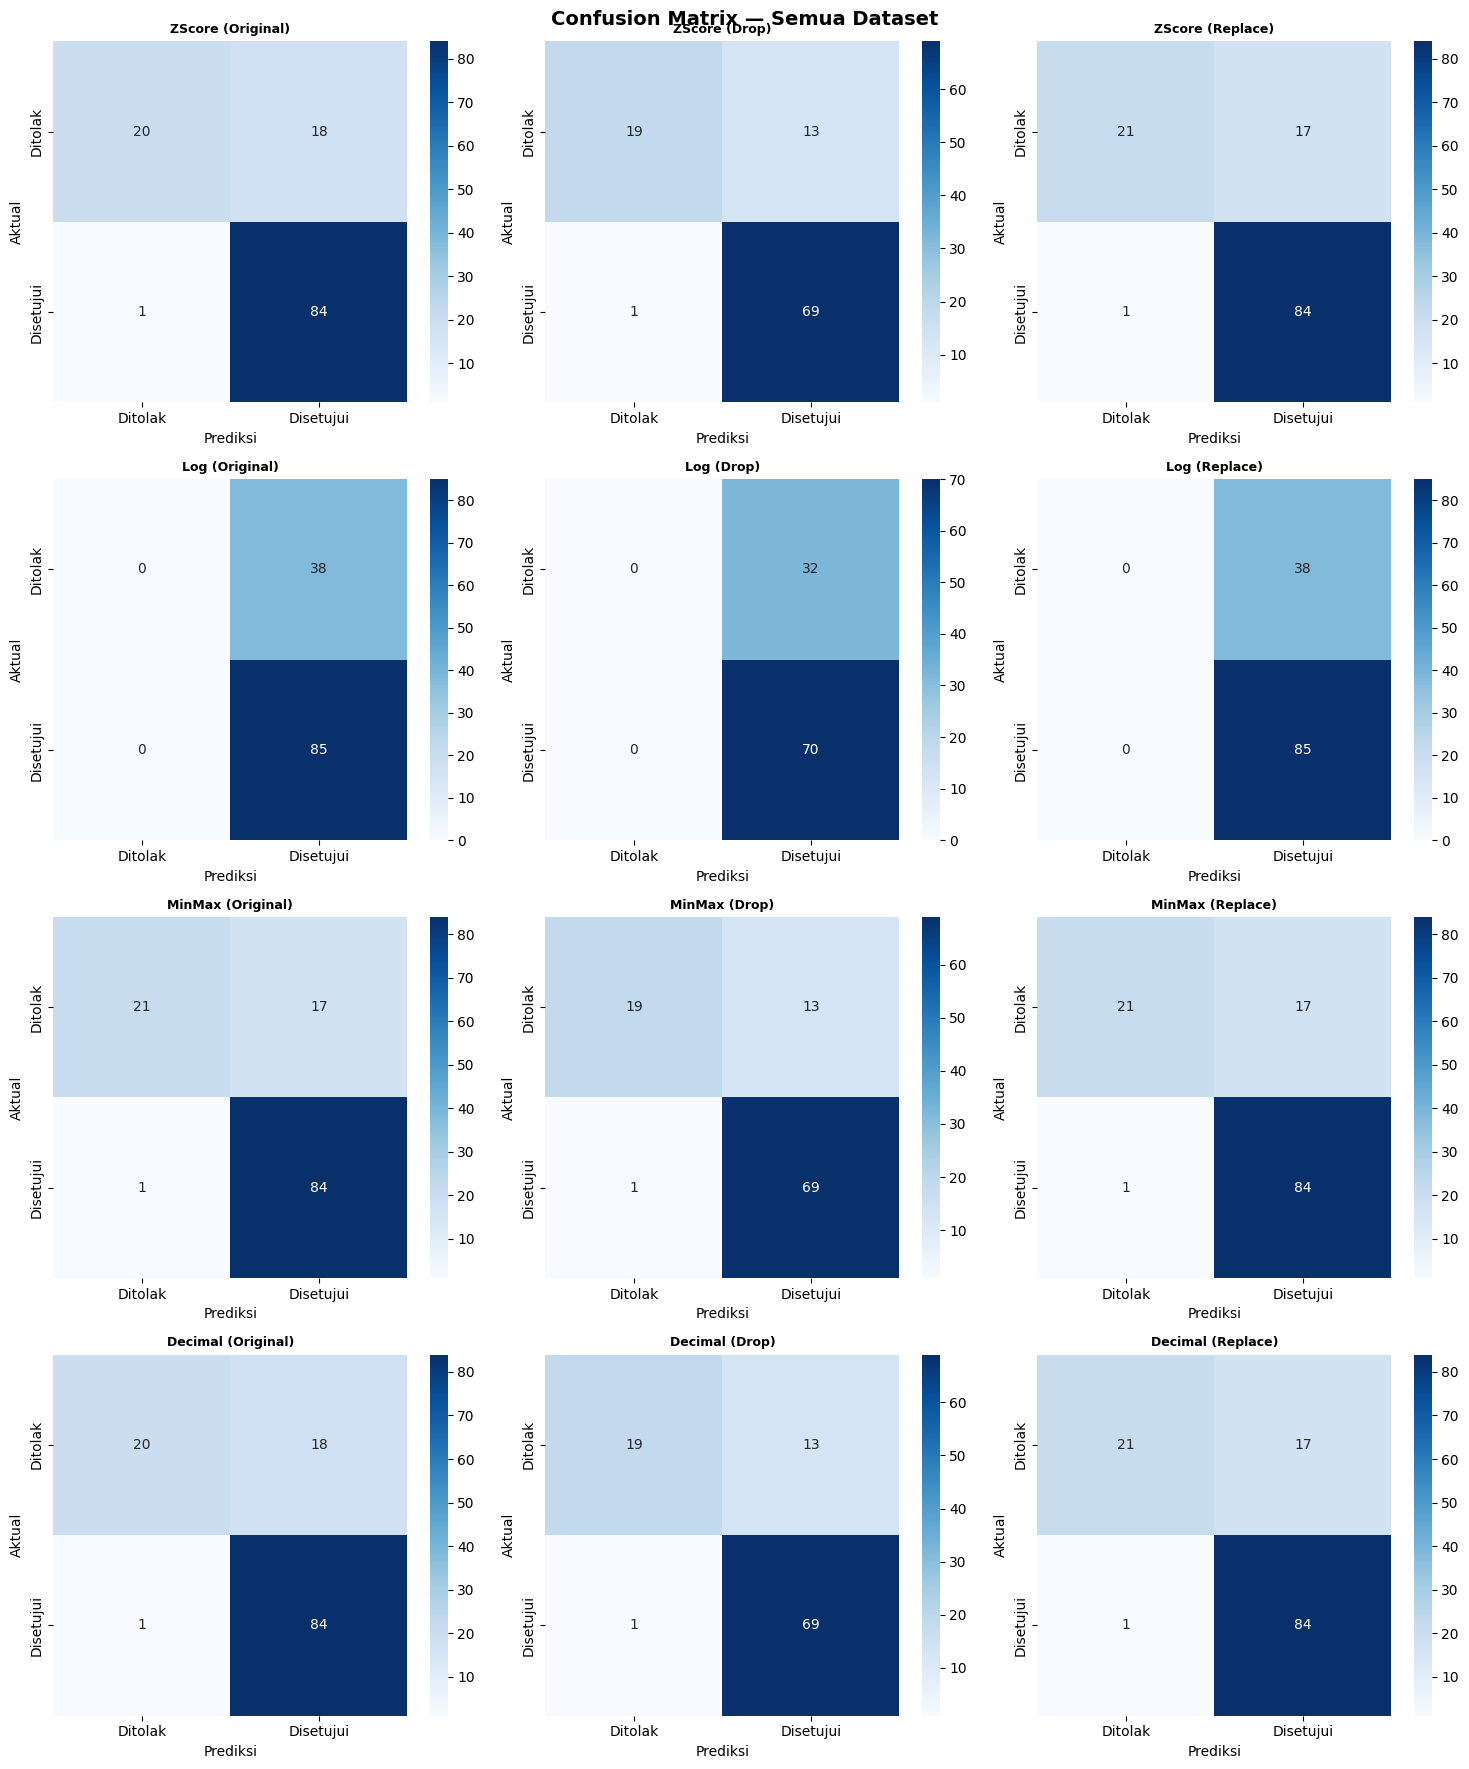

In [27]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.suptitle('Confusion Matrix — Semua Dataset', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), results.items()):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ditolak','Disetujui'],
        yticklabels=['Ditolak','Disetujui'],
        ax=ax
    )
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

## 8. Classification Report Detail


In [28]:
for name, res in results.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        res['y_test'], res['y_pred'],
        target_names=['Ditolak (0)', 'Disetujui (1)'],
        zero_division=0
    ))
    print()

  ZScore (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.95      0.53      0.68        38
Disetujui (1)       0.82      0.99      0.90        85

     accuracy                           0.85       123
    macro avg       0.89      0.76      0.79       123
 weighted avg       0.86      0.85      0.83       123


  ZScore (Drop)
               precision    recall  f1-score   support

  Ditolak (0)       0.95      0.59      0.73        32
Disetujui (1)       0.84      0.99      0.91        70

     accuracy                           0.86       102
    macro avg       0.90      0.79      0.82       102
 weighted avg       0.88      0.86      0.85       102


  ZScore (Replace)
               precision    recall  f1-score   support

  Ditolak (0)       0.95      0.55      0.70        38
Disetujui (1)       0.83      0.99      0.90        85

     accuracy                           0.85       123
    macro avg       0.89      0.77      0.80       123


---
# XAI — Explainable Artificial Intelligence (SHAP)
SHAP (SHapley Additive exPlanations) menjelaskan **kontribusi setiap fitur** terhadap prediksi model.
- **Nilai SHAP positif** → fitur mendorong prediksi ke arah **Disetujui (1)**
- **Nilai SHAP negatif** → fitur mendorong prediksi ke arah **Ditolak (0)**
### Jenis plot yang digunakan:
| Plot | Fungsi |
|---|---|
| **Summary Bar** | Rata-rata kontribusi absolut tiap fitur (global) |
| **Beeswarm** | Distribusi nilai SHAP seluruh data test (global) |
| **Waterfall** | Breakdown kontribusi fitur untuk 1 prediksi (lokal) |
| **Force Plot** | Visualisasi push/pull fitur untuk 1 prediksi (lokal) |


## 9. Hitung SHAP Values (Semua Dataset)
> Proses ini memakan waktu karena menggunakan `KernelExplainer` yang cocok untuk LightGBM.
> Background sample dibatasi 50 data untuk efisiensi.


## 10. SHAP Summary Plot — Bar (Feature Importance Global)
Bar chart menunjukkan **rata-rata kontribusi absolut** tiap fitur di seluruh data test.
Semakin panjang bar → semakin besar pengaruh fitur tersebut terhadap prediksi model.


## 11. SHAP Beeswarm Plot (Distribusi SHAP Global)
Beeswarm menunjukkan distribusi nilai SHAP untuk setiap fitur di seluruh data test.
- **Warna merah** = nilai fitur tinggi
- **Warna biru** = nilai fitur rendah
- **Posisi kanan (positif)** = mendorong ke Disetujui
- **Posisi kiri (negatif)** = mendorong ke Ditolak


## 12. SHAP Waterfall Plot (Penjelasan Lokal per Prediksi)
Waterfall plot menjelaskan **satu prediksi spesifik** secara detail:
- Dimulai dari expected value (rata-rata prediksi model)
- Setiap fitur menambah atau mengurangi nilai prediksi
- Diambil **sampel index ke-0** dari data test tiap dataset


## 13. SHAP Force Plot (Visualisasi Push/Pull per Prediksi)
Force plot menunjukkan fitur mana yang **mendorong (merah)** atau **menahan (biru)** prediksi.
- Diambil **sampel index ke-0** dari data test tiap dataset


## 14. Rekap Feature Importance SHAP — Semua Dataset
Tabel perbandingan **rata-rata |SHAP value|** tiap fitur di semua 12 dataset.
Memudahkan analisis fitur mana yang konsisten berpengaruh di semua transformasi.


## 15. Prediksi Data Baru (Semua Model)
Uji prediksi dengan satu sampel data baru di semua 12 model.


In [36]:
# ── Isi data baru sesuai kebutuhan ─────────────────────────────────
new_data_raw = {
    'Gender'            : 1,
    'Married'           : 1,
    'Dependents'        : 0.0,
    'Education'         : 1,
    'Self_Employed'     : 0,
    'ApplicantIncome'   : 5000,
    'CoapplicantIncome' : 1500,
    'LoanAmount'        : 150,
    'Loan_Amount_Term'  : 360,
    'Credit_History'    : 0.0,
    'Property_Area'     : 1,
    'Total_Income'      : 6500,
    'Loan_Amount_Income_Ratio': (150/6500) + 1,
}
new_df = pd.DataFrame([new_data_raw])
print('Data baru:')
print(new_df.T)


Data baru:
                        0
Gender                1.0
Married               1.0
Dependents            0.0
Education             1.0
Self_Employed         0.0
ApplicantIncome    5000.0
CoapplicantIncome  1500.0
LoanAmount          150.0
Loan_Amount_Term    360.0
Credit_History        0.0
Property_Area         1.0
Total_Income       6500.0


In [37]:
print('HASIL PREDIKSI DATA BARU — SEMUA MODEL')
print('='*60)

new_pred_records = []

for name, res in results.items():
    cols  = res['feature_names']
    model = res['model']

    if not all(c in new_df.columns for c in cols):
        print(f'{name:30s} : Kolom tidak lengkap, skip')
        continue

    pred_raw   = model.predict(new_df[cols])[0]
    pred_label = 1 if pred_raw >= 0.5 else 0
    status     = 'DISETUJUI ✅' if pred_label == 1 else 'DITOLAK ❌'

    print(f'{name:30s} : {status}  (raw={pred_raw:.4f})')
    new_pred_records.append({
        'Dataset' : name,
        'Raw'     : round(pred_raw, 4),
        'Label'   : pred_label,
        'Status'  : 'Disetujui' if pred_label == 1 else 'Ditolak'
    })

pred_df = pd.DataFrame(new_pred_records)
print('='*60)
print(f"Disetujui: {(pred_df['Label']==1).sum()} model | Ditolak: {(pred_df['Label']==0).sum()} model")

HASIL PREDIKSI DATA BARU — SEMUA MODEL
ZScore (Original)              : DISETUJUI ✅  (raw=1.0000)
ZScore (Drop)                  : DISETUJUI ✅  (raw=1.0000)
ZScore (Replace)               : DISETUJUI ✅  (raw=1.0000)
Log (Original)                 : DISETUJUI ✅  (raw=1.0000)
Log (Drop)                     : DISETUJUI ✅  (raw=1.0000)
Log (Replace)                  : DISETUJUI ✅  (raw=1.0000)
MinMax (Original)              : DISETUJUI ✅  (raw=1.0000)
MinMax (Drop)                  : DISETUJUI ✅  (raw=1.0000)
MinMax (Replace)               : DISETUJUI ✅  (raw=1.0000)
Decimal (Original)             : DISETUJUI ✅  (raw=1.0000)
Decimal (Drop)                 : DISETUJUI ✅  (raw=1.0000)
Decimal (Replace)              : DISETUJUI ✅  (raw=1.0000)
Disetujui: 12 model | Ditolak: 0 model


## 16. Ringkasan Akhir & Rekomendasi


In [38]:
print('RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)')
print('='*70)
print(summary.to_string(index=False))
best  = summary.iloc[0]
worst = summary.iloc[-1]
print(f'\n🏆 Model TERBAIK   : {best["Dataset"]}')
print(f'   F1={best["F1 Score"]:.4f} | Precision={best["Precision"]:.4f} | Recall={best["Recall"]:.4f} | Accuracy={best["Accuracy"]:.4f}')
print(f'\n⚠️  Model TERENDAH  : {worst["Dataset"]}')
print(f'   F1={worst["F1 Score"]:.4f} | Precision={worst["Precision"]:.4f} | Recall={worst["Recall"]:.4f} | Accuracy={worst["Accuracy"]:.4f}')


RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)
           Dataset  Accuracy  Precision  Recall  F1 Score
     ZScore (Drop)    0.8627     0.8415  0.9857    0.9079
     MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
    Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
  ZScore (Replace)    0.8537     0.8317  0.9882    0.9032
 Decimal (Replace)    0.8537     0.8317  0.9882    0.9032
 MinMax (Original)    0.8537     0.8317  0.9882    0.9032
  MinMax (Replace)    0.8537     0.8317  0.9882    0.9032
 ZScore (Original)    0.8455     0.8235  0.9882    0.8984
Decimal (Original)    0.8455     0.8235  0.9882    0.8984
    Log (Original)    0.6911     0.6911  1.0000    0.8173
     Log (Replace)    0.6911     0.6911  1.0000    0.8173
        Log (Drop)    0.6863     0.6863  1.0000    0.8140

🏆 Model TERBAIK   : ZScore (Drop)
   F1=0.9079 | Precision=0.8415 | Recall=0.9857 | Accuracy=0.8627

⚠️  Model TERENDAH  : Log (Drop)
   F1=0.8140 | Precision=0.6863 | Recall=1.0000 | Accuracy=0.6863